In [221]:
pip install tensorflow


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [222]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential

## Data Generation: Sine Curves

Generate **10,000 sine curves** of the form:

$$
x(t) = A \cdot \sin(\omega t + \phi)
$$

where the parameters are drawn from uniform distributions:

- Amplitude: $ A \sim \mathcal{U}[0.5, 1.5] $
- Frequency: $ \omega \sim \mathcal{U}[0.5, 2] $
- Phase: $ \phi \sim \mathcal{U}[0, 2\pi] $

Sample each curve at $N = 100$ equally spaced points over $t \in [0, 4\pi]$.
Your clean_curve array should have shape (10000, 100).

In [223]:
# generate dataset

N = 10000
res = 100

clean_sample = np.zeros([N,res])
t = np.linspace(0, 4*np.pi, res)

for n in range(N):

    amp = np.random.rand()+0.5
    freq = np.random.rand()*1.5+0.5
    phase = np.random.rand()*2*np.pi

    clean_sample[n] = amp * np.sin(freq * t + phase)

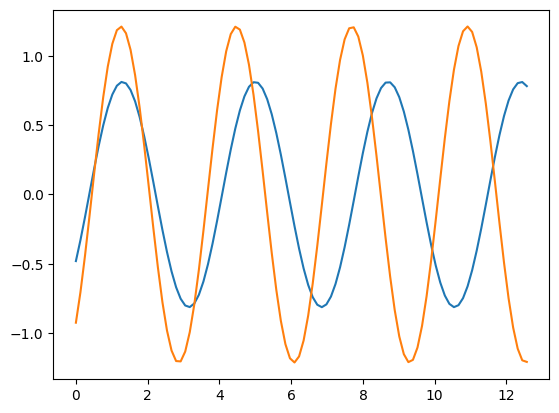

In [224]:
plt.plot(t, clean_sample[67])
plt.plot(t, clean_sample[6767])

## Add Gaussian Noise

$$
x_{\text{noisy}}(t) = x(t) + \epsilon, \qquad \epsilon \sim \mathcal{N}(0, \sigma^2), \quad \sigma = 0.2
$$
Your noisy_curve array should have shape (10000, 100).

In [225]:
# generate noisy data

sigma = 0.2
noise_arr = np.random.normal(0, sigma**2, [N,res])

noisy_sample = clean_sample+noise_arr

Plot examples showing the clean and noisy curve.

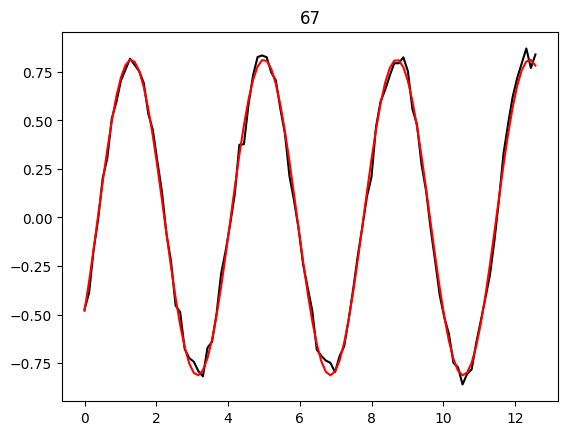

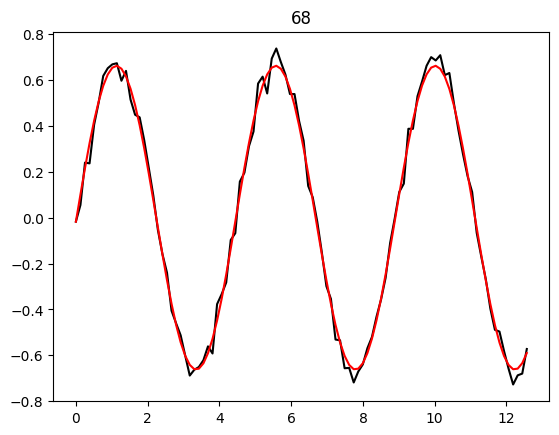

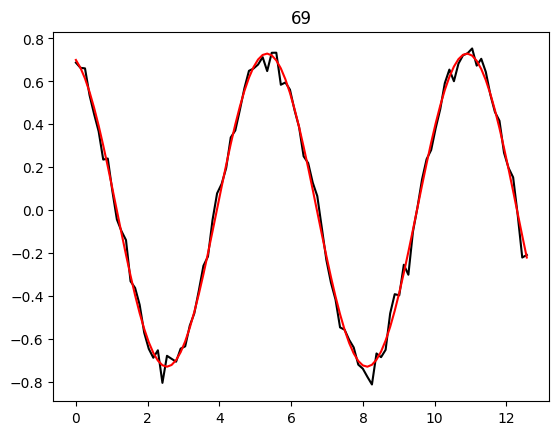

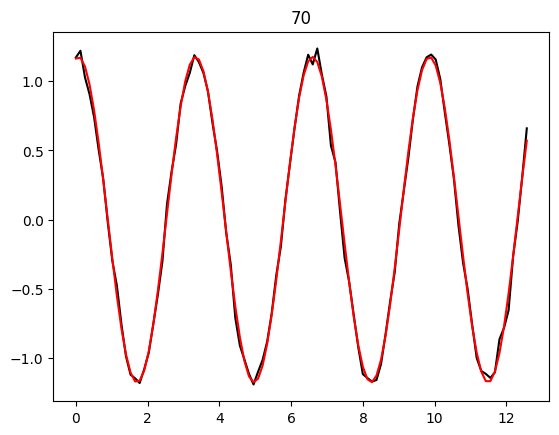

In [226]:
# plot clean vs noisy examples

plt.plot(t, noisy_sample[67], color='black')
plt.plot(t, clean_sample[67], color='red')
plt.title('67')
plt.show()

plt.plot(t, noisy_sample[68], color='black')
plt.plot(t, clean_sample[68], color='red')
plt.title('68')
plt.show()

plt.plot(t, noisy_sample[69], color='black')
plt.plot(t, clean_sample[69], color='red')
plt.title('69')
plt.show()

plt.plot(t, noisy_sample[70], color='black')
plt.plot(t, clean_sample[70], color='red')
plt.title('70')
plt.show()

## Dataset Split

Split into **90% training / 10% validation**.
- **Input**  (noisy_curve) : X_train -> shape (9000, 100), X_val -> shape (1000, 100)
- **Target** (clean_curve): Y_train -> shape (9000, 100), Y_val -> shape (1000, 100)

In [227]:
# dataset split

n_train = int(0.9 * len(clean_sample))

noisy_train = noisy_sample[:n_train]
noisy_test = noisy_sample[n_train:]

clean_train = clean_sample[:n_train]
clean_test = clean_sample[n_train:]

## Autoencoder Model

**Fully connected (dense) autoencoder**
- **Encoder** compresses the input into a low-dimensional **latent space**
- **Decoder** reconstructs the signal from the latent representation

The network is trained to minimise **mean squared error (MSE)** between the reconstructed and clean signal.

In [228]:
autoencoder = Sequential([
    Input(shape=(res,)),
    Dense(64, activation='relu'),
    Dense(16, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(res,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_69"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_294 (Dense)               │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_295 (Dense)               │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_296 (Dense)               │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_297 (Dense)               │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,092 (58.95 KB)

 Trainable params: 15,092 (58.95 KB)

 Non-trainable params: 0 (0.00 B)

## Training with .fit()

.fit() trains the model. The key arguments are:

| Argument | What it means |
|---|---|
| X_train, Y_train | The data the model learns from |
| epochs | How many times the model sees the full training data |
| batch_size | How many samples to process before updating the weights |
| validation_data=(X_val, Y_val) | Data the model never trains on. It is used to check performance after each epoch |
| verbose=1 | Shows a progress bar while training; set to 0 to hide it |

After training, history stores the training loss and validation loss at every epoch:

If validation loss starts increasing while training loss keeps decreasing -> the model is **overfitting** (memorising the training data instead of generalising).

In [229]:
clean_train.shape

(9000, 100)

In [230]:
history = autoencoder.fit(
    noisy_train, clean_train,
    epochs=50,
    batch_size=128,
    validation_data=(noisy_test, clean_test),
    verbose=1
)


Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3717 - val_loss: 0.1194
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0539 - val_loss: 0.0244
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0147 - val_loss: 0.0090
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0081 - val_loss: 0.0065
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0061 - val_loss: 0.0049
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0045 - val_loss: 0.0037
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0035 - val_loss: 0.0031
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0029 - val_loss: 0.0025
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0024 - val_loss: 0.0021
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0021 - val_loss: 0.0019
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0018 - val_loss: 0.0017
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0016 - val_lo

Plot the training and validation loss curves.

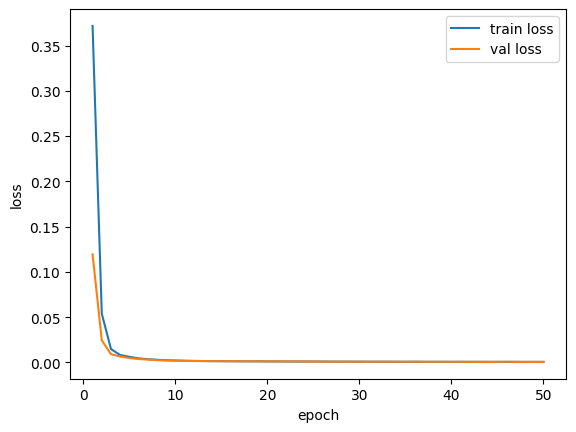

In [231]:
# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

# plot loss curves
plt.plot(epochs_range, train_loss, label = 'train loss')
plt.plot(epochs_range, val_loss, label='val loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()


## Making Predictions with .predict()

model.predict(X) passes the input array through the trained network and returns reconstructed outputs.

In [232]:
examples = [0, 1, 2, 3]

reconstructed_Y = autoencoder.predict(noisy_test[examples]) # Returns shape (4, 100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


Plot the clean signal, noisy input, and reconstructed signal.

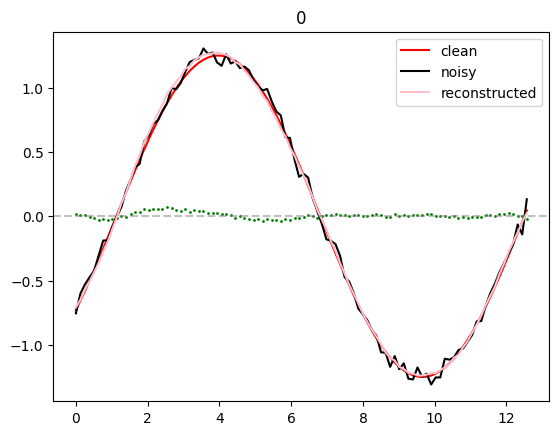

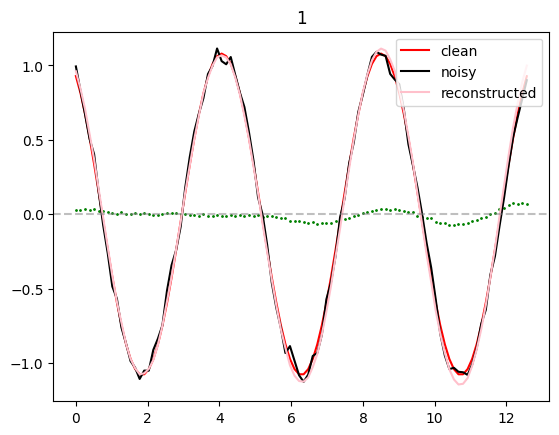

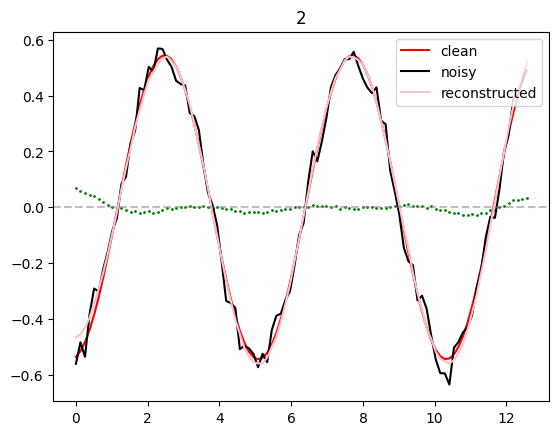

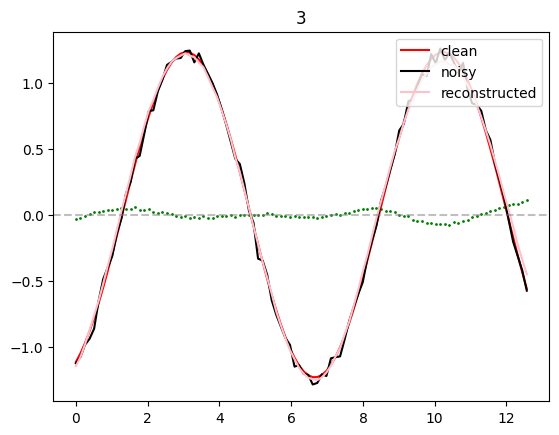

In [233]:
# Plot clean / noisy / reconstructed for each example

for i in examples:
    plt.plot(t, clean_test[i], label='clean', color='red')
    plt.plot(t, noisy_test[i], label='noisy', color='black')
    plt.plot(t, reconstructed_Y[i], label='reconstructed', color='pink')

    plt.scatter(t, (reconstructed_Y[i] - clean_test[i]), color='green', s=1)
    plt.axhline(0, linestyle='--', color='grey', alpha=0.5)

    plt.legend(loc='upper right')
    plt.title(f'{i}')
    plt.show()

Residuals between clean and reconstructed signals are shown in green

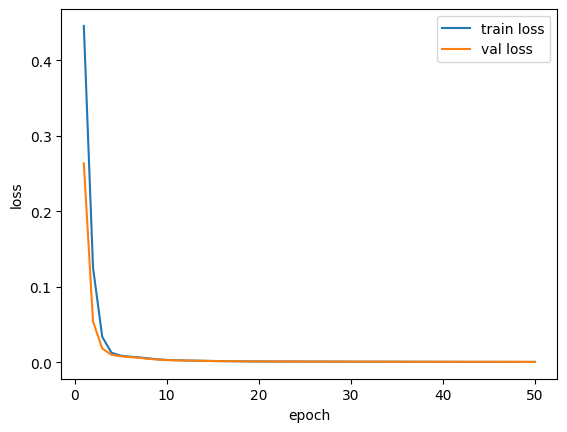

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


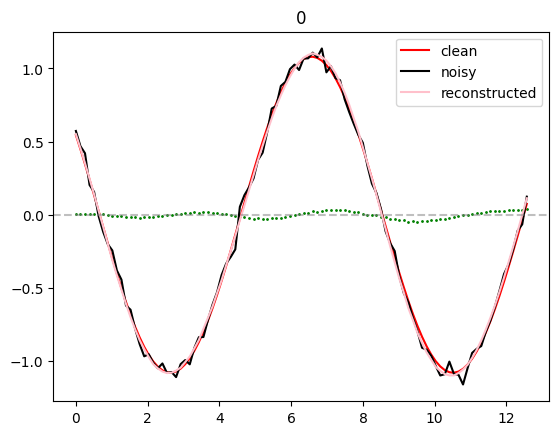

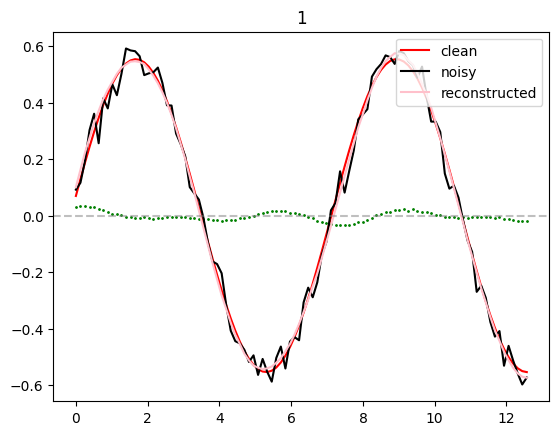

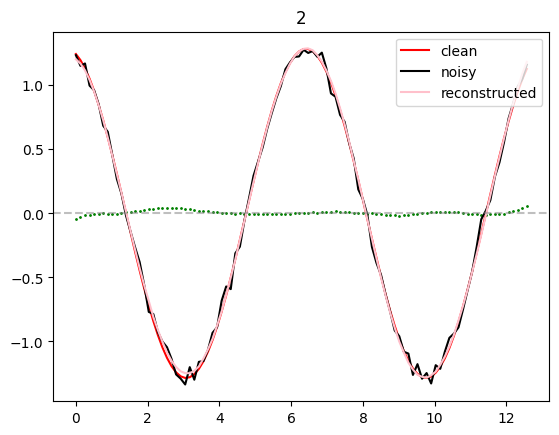

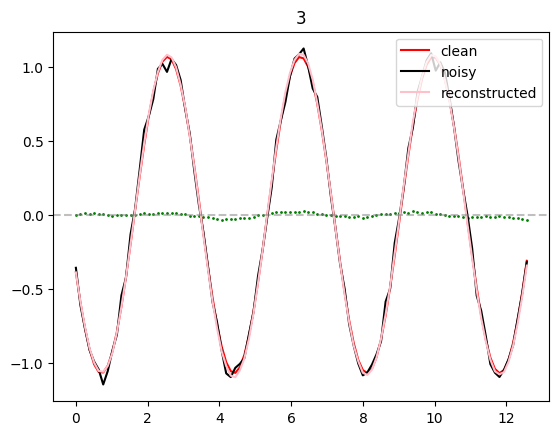

In [ ]:
n_train_a1 = int(0.6 * len(clean_sample))

noisy_train_a1 = noisy_sample[:n_train_a1]
noisy_test_a1 = noisy_sample[n_train_a1:]

clean_train_a1 = clean_sample[:n_train_a1]
clean_test_a1 = clean_sample[n_train_a1:]

autoencoder_a1 = Sequential([
    Input(shape=(res,)),
    Dense(64, activation='relu'),
    Dense(16, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(res,  activation='linear') # output layer
])

autoencoder_a1.compile(optimizer=Adam(0.001), loss='mse')

history_a1 = autoencoder_a1.fit(
    noisy_train_a1, clean_train_a1,
    epochs=50,
    batch_size=128,
    validation_data=(noisy_test_a1, clean_test_a1),
    verbose=0
)

train_loss_a1   = history_a1.history['loss'] 
val_loss_a1     = history_a1.history['val_loss'] 
epochs_range_a1 = range(1, len(train_loss_a1) + 1)


plt.plot(epochs_range_a1, train_loss_a1, label = 'train loss')
plt.plot(epochs_range_a1, val_loss_a1, label='val loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

examples_a1 = [0, 1, 2, 3]

reconstructed_Y_a1 = autoencoder.predict(noisy_test_a1[examples])

for i in examples_a1:
    plt.plot(t, clean_test_a1[i], label='clean', color='red')
    plt.plot(t, noisy_test_a1[i], label='noisy', color='black')
    plt.plot(t, reconstructed_Y_a1[i], label='reconstructed', color='pink')

    plt.scatter(t, (reconstructed_Y_a1[i] - clean_test_a1[i]), color='green', s=1)
    plt.axhline(0, linestyle='--', color='grey', alpha=0.5)

    plt.legend(loc='upper right')
    plt.title(f'{i}')
    plt.show()

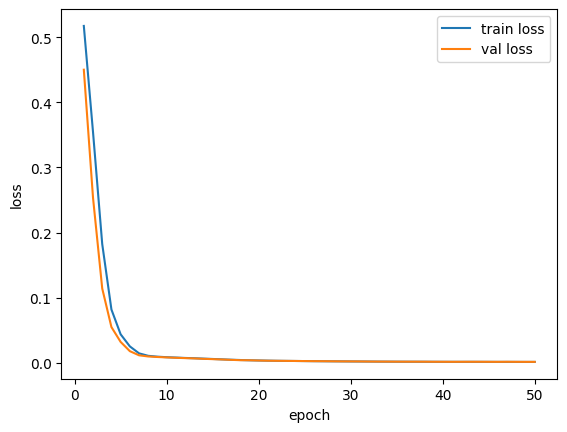

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


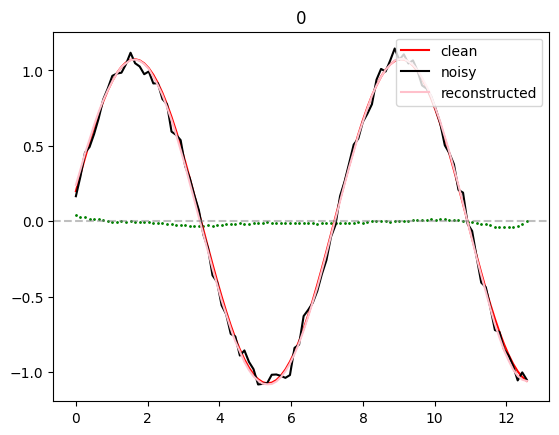

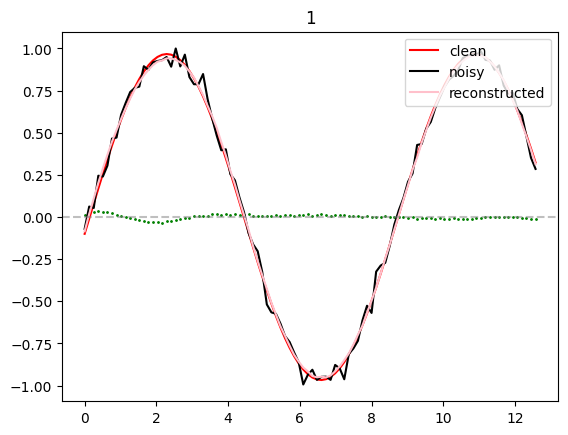

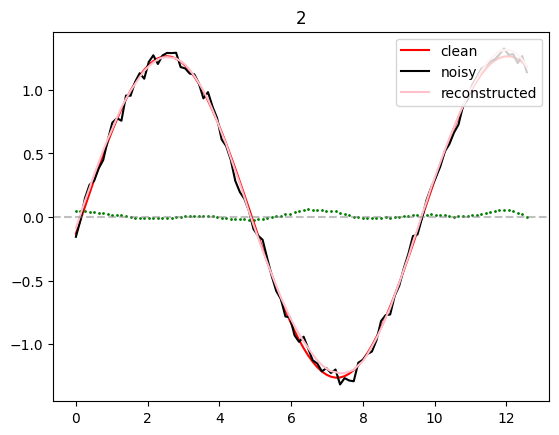

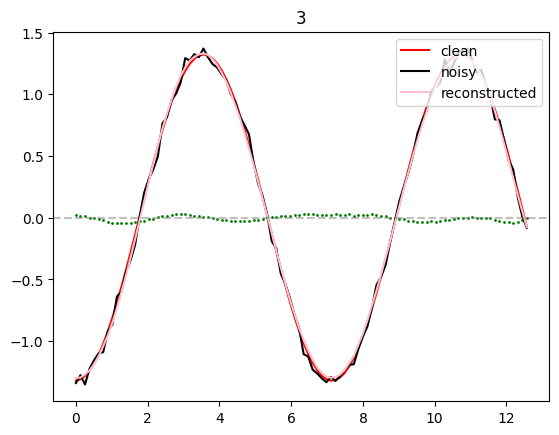

In [244]:
n_train_a2 = int(0.3 * len(clean_sample))

noisy_train_a2 = noisy_sample[:n_train_a2]
noisy_test_a2 = noisy_sample[n_train_a2:]

clean_train_a2 = clean_sample[:n_train_a2]
clean_test_a2 = clean_sample[n_train_a2:]

autoencoder_a2 = Sequential([
    Input(shape=(res,)),
    Dense(64, activation='relu'),
    Dense(16, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(res,  activation='linear') # output layer
])

autoencoder_a2.compile(optimizer=Adam(0.001), loss='mse')

history_a2 = autoencoder_a2.fit(
    noisy_train_a2, clean_train_a2,
    epochs=50,
    batch_size=128,
    validation_data=(noisy_test_a2, clean_test_a2),
    verbose=0
)

train_loss_a2   = history_a2.history['loss'] 
val_loss_a2     = history_a2.history['val_loss'] 
epochs_range_a2 = range(1, len(train_loss_a2) + 1)


plt.plot(epochs_range_a2, train_loss_a2, label = 'train loss')
plt.plot(epochs_range_a2, val_loss_a2, label='val loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()


examples_a2 = [0, 1, 2, 3]

reconstructed_Y_a2 = autoencoder.predict(noisy_test_a2[examples])

for i in examples_a1:
    plt.plot(t, clean_test_a2[i], label='clean', color='red')
    plt.plot(t, noisy_test_a2[i], label='noisy', color='black')
    plt.plot(t, reconstructed_Y_a2[i], label='reconstructed', color='pink')

    plt.scatter(t, (reconstructed_Y_a2[i] - clean_test_a2[i]), color='green', s=1)
    plt.axhline(0, linestyle='--', color='grey', alpha=0.5)

    plt.legend(loc='upper right')
    plt.title(f'{i}')
    plt.show()

In [245]:
decoded = autoencoder.predict(noisy_test)

mse = np.mean((clean_test - decoded)**2, axis=1)

print("Average sample MSE:", np.mean(mse))
print("Best reconstruction MSE:", np.min(mse))
print("Worst reconstruction MSE:", np.max(mse))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 568us/step
Average sample MSE: 0.000358947979538849
Best reconstruction MSE: 5.5158333843106896e-05
Worst reconstruction MSE: 0.0012787571172437303


In [246]:
decoded_a1 = autoencoder_a1.predict(noisy_test_a1)

mse_a1 = np.mean((clean_test_a1 - decoded_a1)**2, axis=1)

print("Average sample MSE:", np.mean(mse_a1))
print("Best reconstruction MSE:", np.min(mse_a1))
print("Worst reconstruction MSE:", np.max(mse_a1))

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 349us/step
Average sample MSE: 0.0006993091802815224
Best reconstruction MSE: 8.77799299788818e-05
Worst reconstruction MSE: 0.007536566269591958


In [247]:
decoded_a2 = autoencoder_a2.predict(noisy_test_a2)

mse_a2 = np.mean((clean_test_a2 - decoded_a2)**2, axis=1)

print("Average sample MSE:", np.mean(mse_a2))
print("Best reconstruction MSE:", np.min(mse_a2))
print("Worst reconstruction MSE:", np.max(mse_a2))

219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 402us/step
Average sample MSE: 0.0012350318772592253
Best reconstruction MSE: 0.00012351616379204208
Worst reconstruction MSE: 0.015068826169166195


In [257]:
autoencoder_b1 = Sequential([
    Input(shape=(res,)),
    Dense(64, activation='relu'),
    Dense(4, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(res,  activation='linear') # output layer
])

autoencoder_b1.compile(optimizer=Adam(0.001), loss='mse')

autoencoder_b2 = Sequential([
    Input(shape=(res,)),
    Dense(80, activation='relu'),
    Dense(40, activation='relu'),
    Dense(4, activation='relu'),  # latent (bottleneck) layer
    Dense(40, activation='relu'),
    Dense(80, activation='relu'),
    Dense(res,  activation='linear') # output layer
])

autoencoder_b2.compile(optimizer=Adam(0.001), loss='mse')

autoencoder_b3 = Sequential([
    Input(shape=(res,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(4, activation='relu'),  # latent (bottleneck) layer
    Dense(16, activation='relu'),
    Dense(32, activation='relu'),
    Dense(64, activation='relu'),
    Dense(res,  activation='linear') # output layer
])

autoencoder_b3.compile(optimizer=Adam(0.001), loss='mse')

In [258]:
import time

The time for [64,4,64] is 4.841135740280151s with a MSE of 0.01676415093243122.


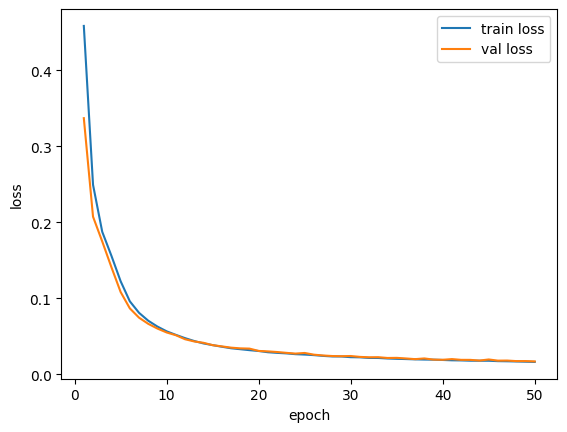

In [259]:
start = time.time()

history_b1 = autoencoder_b1.fit(
    noisy_train, clean_train,
    epochs=50,
    batch_size=128,
    validation_data=(noisy_test, clean_test),
    verbose=0
)

end = time.time()

time_b1 = end - start
mse_b1 = history_b1.history['val_loss'][-1]

print(f'The time for [64,4,64] is {time_b1}s with a MSE of {mse_b1}.')

train_loss_b1   = history_b1.history['loss'] 
val_loss_b1     = history_b1.history['val_loss'] 
epochs_range_b1 = range(1, len(train_loss_b1) + 1)


plt.plot(epochs_range_b1, train_loss_b1, label = 'train loss')
plt.plot(epochs_range_b1, val_loss_b1, label='val loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

The time for [80,40,4,40,80] is 6.203877925872803s with a MSE of 0.0059431325644254684.


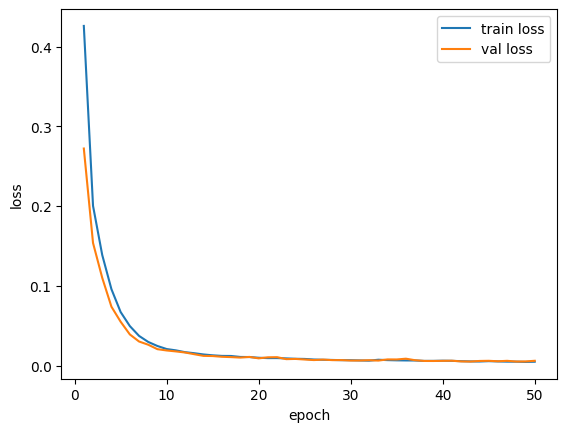

In [260]:
start = time.time()

history_b2 = autoencoder_b2.fit(
    noisy_train, clean_train,
    epochs=50,
    batch_size=128,
    validation_data=(noisy_test, clean_test),
    verbose=0
)

end = time.time()

time_b2 = end - start
mse_b2 = history_b2.history['val_loss'][-1]

print(f'The time for [80,40,4,40,80] is {time_b2}s with a MSE of {mse_b2}.')

train_loss_b2   = history_b2.history['loss'] 
val_loss_b2     = history_b2.history['val_loss'] 
epochs_range_b2 = range(1, len(train_loss_b2) + 1)


plt.plot(epochs_range_b2, train_loss_b2, label = 'train loss')
plt.plot(epochs_range_b2, val_loss_b2, label='val loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

The time for [64,32,16,4,16,32,64] is 6.243855953216553s with a MSE of 0.004537962377071381.


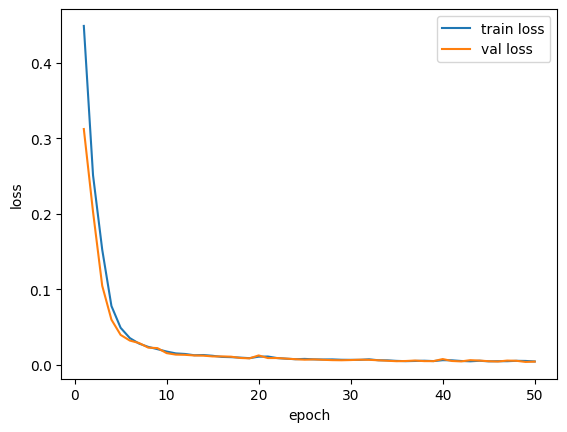

In [261]:
start = time.time()

history_b3 = autoencoder_b3.fit(
    noisy_train, clean_train,
    epochs=50,
    batch_size=128,
    validation_data=(noisy_test, clean_test),
    verbose=0
)

end = time.time()

time_b3 = end - start
mse_b3 = history_b3.history['val_loss'][-1]

print(f'The time for [64,32,16,4,16,32,64] is {time_b3}s with a MSE of {mse_b3}.')

train_loss_b3   = history_b3.history['loss'] 
val_loss_b3     = history_b3.history['val_loss'] 
epochs_range_b3 = range(1, len(train_loss_b3) + 1)


plt.plot(epochs_range_b3, train_loss_b3, label = 'train loss')
plt.plot(epochs_range_b3, val_loss_b3, label='val loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


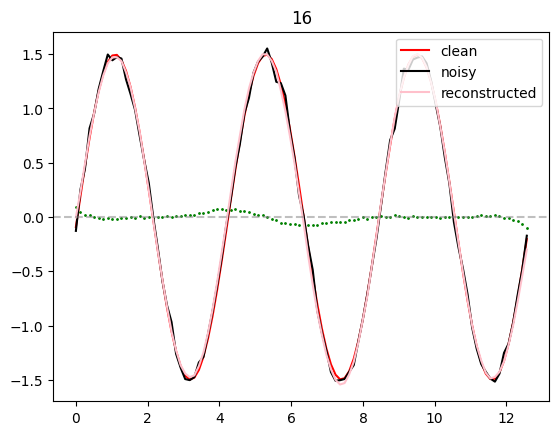

The MSE for a bottleneck layer of n=16 is MSE=0.00048569447244517505
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


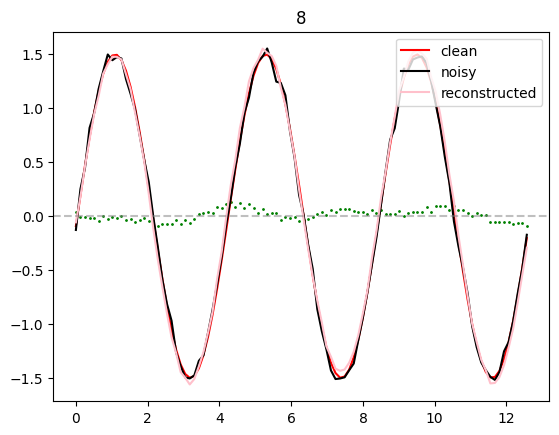

The MSE for a bottleneck layer of n=8 is MSE=0.001955408602952957
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


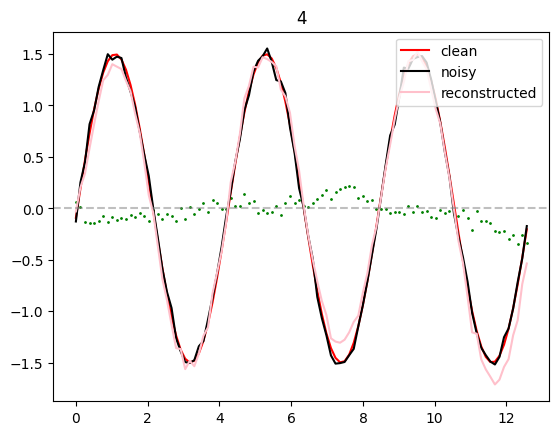

The MSE for a bottleneck layer of n=4 is MSE=0.017700104042887688
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


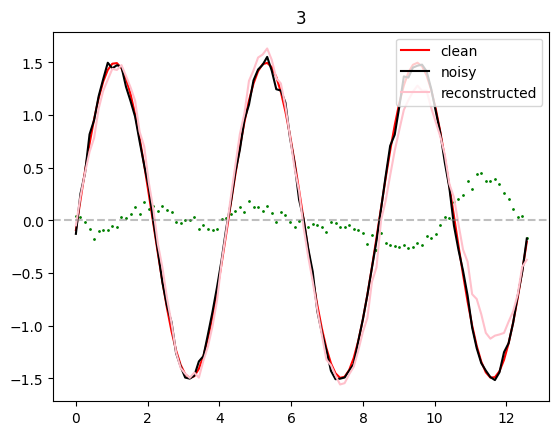

The MSE for a bottleneck layer of n=3 is MSE=0.07321847230195999
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


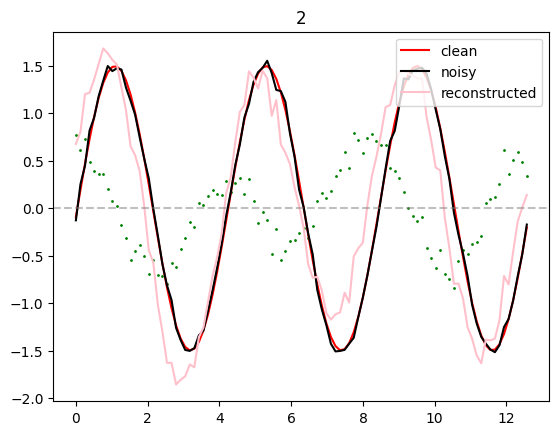

The MSE for a bottleneck layer of n=2 is MSE=0.18229593336582184
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


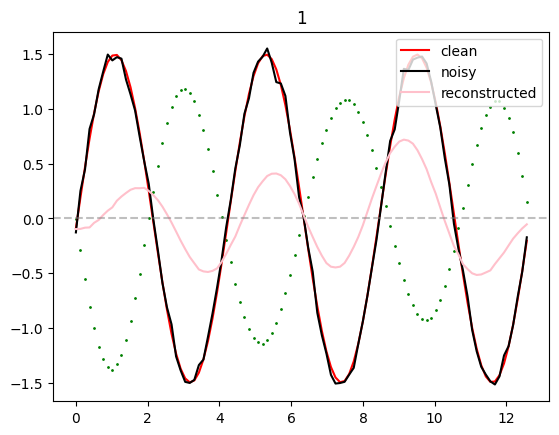

The MSE for a bottleneck layer of n=1 is MSE=0.410945862531662


In [262]:
n_bottle = [16,8,4,3,2,1]
ind = 67

for n in n_bottle:
    autoencoder = Sequential([
    Input(shape=(res,)),
    Dense(64, activation='relu'),
    Dense(n, activation='relu'),  
    Dense(64, activation='relu'),
    Dense(res,  activation='linear') 
])

    autoencoder.compile(optimizer=Adam(0.001), loss='mse')

    history = autoencoder.fit(
    noisy_train, clean_train,
    epochs=50,
    batch_size=128,
    validation_data=(noisy_test, clean_test),
    verbose=0)

    train_loss   = history.history['loss'] 
    val_loss     = history.history['val_loss'] 
    epochs_range = range(1, len(train_loss) + 1)


    reconstructed_Y = autoencoder.predict(noisy_test[ind:ind+1])[0]


    plt.plot(t, clean_test[ind], label='clean', color='red')
    plt.plot(t, noisy_test[ind], label='noisy', color='black')
    plt.plot(t, reconstructed_Y, label='reconstructed', color='pink')

    plt.scatter(t, (reconstructed_Y - clean_test[ind]), color='green', s=1)
    plt.axhline(0, linestyle='--', color='grey', alpha=0.5)

    plt.legend(loc='upper right')
    plt.title(f'{n}')
    plt.show()

    mse = history.history['val_loss'][-1]
    print(f'The MSE for a bottleneck layer of n={n} is MSE={mse}')


In [ ]:
laplace_arr = np.random.laplace(0, 0.1, [N,res])

laplace_sample = clean_sample+laplace_arr

laplace_train = laplace_sample[:n_train]
laplace_test = laplace_sample[n_train:]

la_autoencoder = Sequential([
    Input(shape=(res,)),
    Dense(64, activation='relu'),
    Dense(8, activation='relu'),  
    Dense(64, activation='relu'),
    Dense(res,  activation='linear') 
])

la_autoencoder.compile(optimizer=Adam(0.001), loss='mse')

ga_autoencoder = Sequential([
    Input(shape=(res,)),
    Dense(64, activation='relu'),
    Dense(8, activation='relu'),  
    Dense(64, activation='relu'),
    Dense(res,  activation='linear') 
])

ga_autoencoder.compile(optimizer=Adam(0.001), loss='mse')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


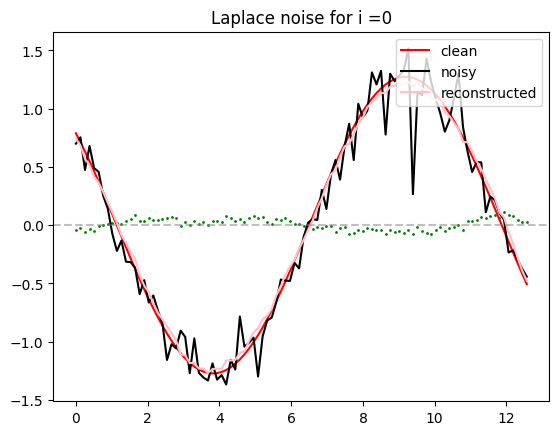

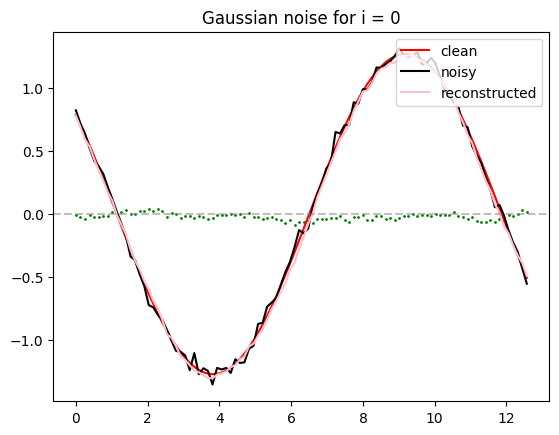

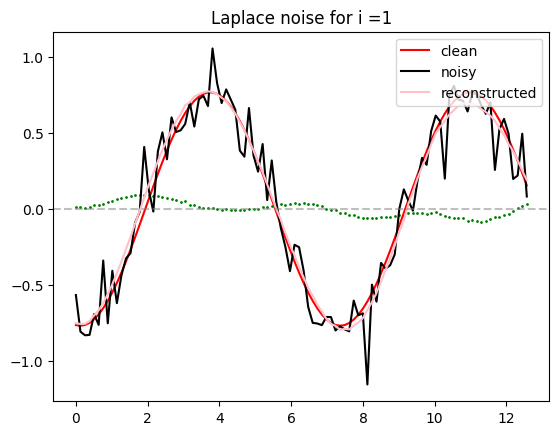

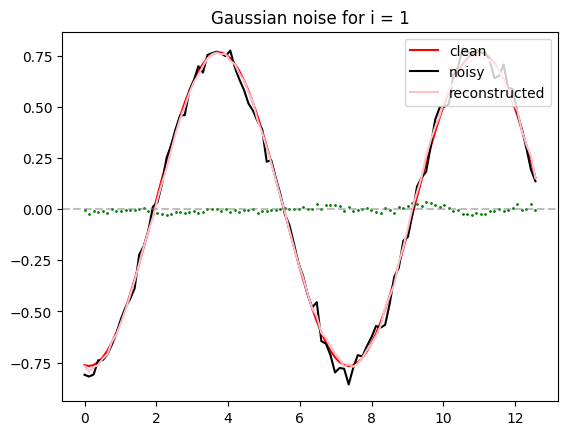

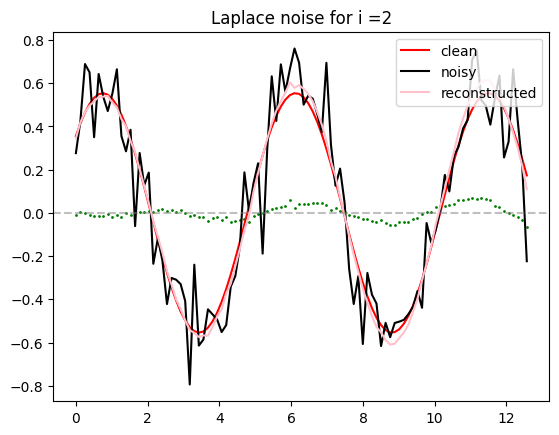

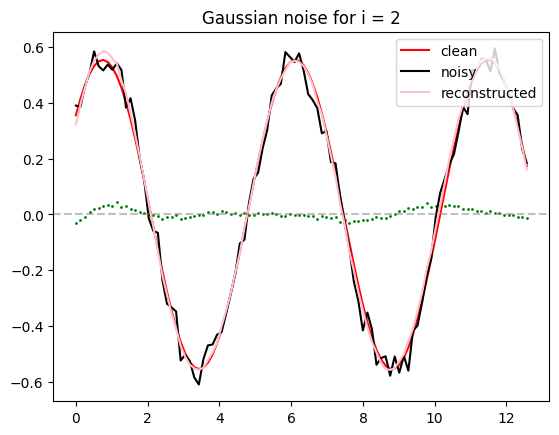

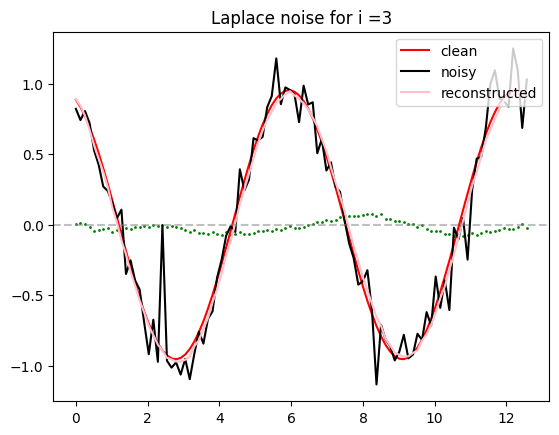

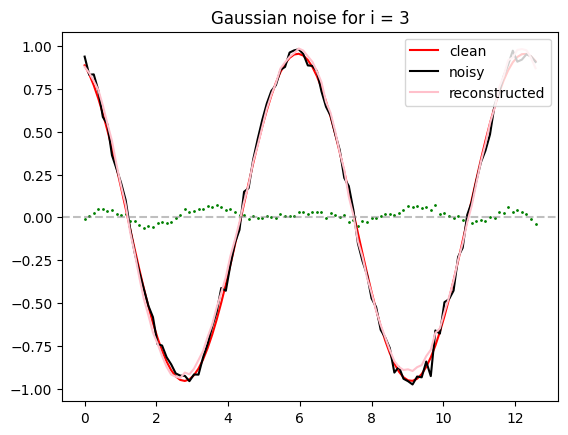

Fitting from Laplacian noise gives MSE=0.002554712351411581, while Gaussian noise gives MSE=0.0011547099566087127.


In [ ]:
la_history = la_autoencoder.fit(
    laplace_train, clean_train,
    epochs=50,
    batch_size=128,
    validation_data=(laplace_test, clean_test),
    verbose=0)

ga_history = ga_autoencoder.fit(
    noisy_train, clean_train,
    epochs=50,
    batch_size=128,
    validation_data=(noisy_test, clean_test),
    verbose=0)

examples = [0, 1, 2, 3]

reconstructed_la = la_autoencoder.predict(laplace_test[examples])
reconstructed_ga = ga_autoencoder.predict(noisy_test[examples])

for i in examples:
    plt.plot(t, clean_test[i], label='clean', color='red')
    plt.plot(t, laplace_test[i], label='noisy', color='black')
    plt.plot(t, reconstructed_la[i], label='reconstructed', color='pink')

    plt.scatter(t, (reconstructed_la[i] - clean_test[i]), color='green', s=1)
    plt.axhline(0, linestyle='--', color='grey', alpha=0.5)

    plt.legend(loc='upper right')
    plt.title(f'Laplace noise for i ={ i}')
    plt.show()


    plt.plot(t, clean_test[i], label='clean', color='red')
    plt.plot(t, noisy_test[i], label='noisy', color='black')
    plt.plot(t, reconstructed_ga[i], label='reconstructed', color='pink')

    plt.scatter(t, (reconstructed_ga[i] - clean_test[i]), color='green', s=1)
    plt.axhline(0, linestyle='--', color='grey', alpha=0.5)

    plt.legend(loc='upper right')
    plt.title(f'Gaussian noise for i = {i}')
    plt.show()

la_mse = la_history.history['val_loss'][-1]
ga_mse = ga_history.history['val_loss'][-1]
print(f'Fitting from Laplacian noise gives MSE={la_mse}, while Gaussian noise gives MSE={ga_mse}.')

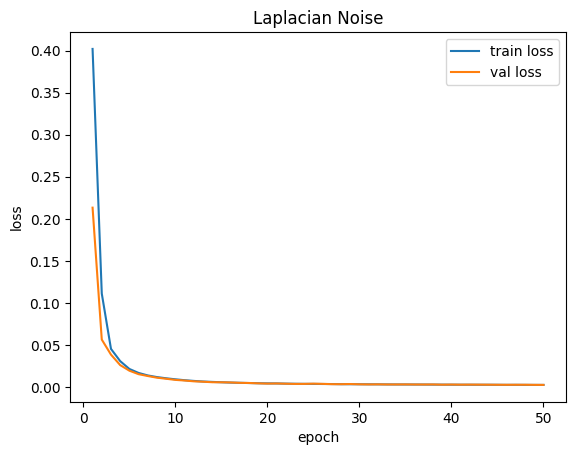

In [264]:
train_loss_la   = la_history.history['loss'] 
val_loss_la     = la_history.history['val_loss'] 
epochs_range_la = range(1, len(train_loss_la) + 1)


plt.plot(epochs_range_la, train_loss_la, label = 'train loss')
plt.plot(epochs_range_la, val_loss_la, label='val loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.title('Laplacian Noise')
plt.show()

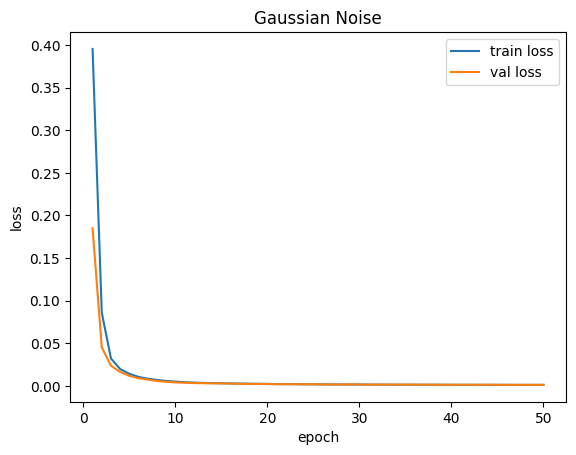

In [265]:
train_loss_ga   = ga_history.history['loss'] 
val_loss_ga     = ga_history.history['val_loss'] 
epochs_range_ga = range(1, len(train_loss_ga) + 1)


plt.plot(epochs_range_ga, train_loss_ga, label = 'train loss')
plt.plot(epochs_range_ga, val_loss_ga, label='val loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.title('Gaussian Noise')
plt.show()